        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-03 04:19:44.302522: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751496584.322711  339463 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751496584.328960  339463 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 04:19:44.349955: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from DWT1DFB import DWT1D, IDWT1D
# from DWT2DFB import DWT2D, IDWT2D


2025-07-03 00:36:15.856100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751483175.876905  262888 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751483175.883276  262888 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 00:36:15.905080: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1751483177.993279  262888 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


In [155]:
# mylibpath = [
#     '/data1/kishoretarafdar/src.port/VolterraMRAsystems.v0/linear.Volterra.mra.live/mra'
#     ]
# import sys
# [sys.path.insert(1,_) for _ in mylibpath]
# del mylibpath
# from DWT1DFB import DWT1D, IDWT1D

In [5]:
import matplotlib.pyplot as plt

#  MIMO batch
        
        export to py file

In [1]:

#%% Shift invariant Linear (m=1) Multiresolution Volterra Kernel
import tensorflow as tf
import keras
from TFDWT.DWT1DFB import DWT1D, IDWT1D

@tf.keras.utils.register_keras_serializable()
class LSIVolterra1Dmra(tf.keras.layers.Layer):
    """ VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
        Input: sequence x[n]
        Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@03Jul2025"""
    
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.wave = wave
        self.filters = filters
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]
   
        kernel_shape = (self.L, input_shape[-1], self.filters)
        # kernel_shape = (self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel')
        super().build(input_shape)

    def __makeH(self):
        paddings = [
        [0, self.N - self.L],  # Depth dimension
        [0,0],
        [0,0]
        ]
        h_padded = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)
        # print(h_padded.shape,'>')

        ## Creating x[n-k] for all n

        n = tf.range(self.N)
        self.row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)

        hshifted = tf.gather(h_padded, self.row_indices, axis=0)
        # print(hshifted.shape,'>')
        # print(tf.concat([tf.transpose(DWT1D(self.wave)(tf.transpose(DWT1D(self.wave)(hshifted[...,i:i+1]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)], axis=-1))

        #### PERFECT but slow
        # HT = tf.stack([
        #         tf.concat([
        #             tf.transpose(DWT1D(self.wave, clean=False)(tf.transpose(DWT1D(self.wave, clean=False)(hshifted[...,i:i+1,j]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)
        #             ], axis=-1) for j in range(self.filters)], axis=-1)
        # # print(HT.shape)
        # return HT

        ## UPDATE
        # Vectorized: flatten last two axes for DWT
        dwt1 = DWT1D(self.wave, clean=False)
        tmp_h_for_dwt = tf.reshape(hshifted, (self.N, self.N, self.channels * self.filters))
        ## x is dummy here
        x = dwt1(tmp_h_for_dwt)           # (N, dwt_len, in_channels*out_channels)
        # 3. Transpose to swap axes 0 and 1 ("rows" and "columns")
        xT = tf.transpose(x, perm=[1, 0, 2])  # (N', N, in_channels * out_channels)

        # 4. DWT1D along the original rows (now axis=1)
        x2 = dwt1(xT)  # (N', N'', in_channels * out_channels)

        # 5. Transpose back to original orientation
        x2T = tf.transpose(x2, perm=[1, 0, 2])  # (N'', N', in_channels * out_channels)

        # 6. Reshape back to (N'', N', in_channels, out_channels)
        HT = tf.reshape(x2T, (self.N, self.N, self.channels, self.channels))
        return HT
        
    
    

    def call(self, x):  
        ## H[v,l] 
        α = DWT1D(self.wave, clean=False)(x) 
        # print('α = ', α.shape)
        HT = self.__makeH()
        print('HT and α', HT.shape, α.shape)
        β = tf.einsum('bic,uico->buco', α, HT)
        β = tf.einsum('buco->buo',β)
        print('β', β.shape)

        # HTα = HT * α
        # print(HTα.shape, '\n', tf.squeeze(HTα).numpy())
        # beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
        
        # βT = tf.transpose(beta, perm=[1,0,2])
        # print('βT',tf.squeeze(βT).numpy())
        y = IDWT1D(self.wave, clean=False)(β)#
        # print('y',tf.squeeze(y).numpy())

        return y#, ynatural
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'wavelet': self.wave,
            'filters': self.filters,
        })
        return config


if __name__=='__main__':

    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"  

    ## Example 1    
    lay = LSIVolterra1Dmra(filters=1)
    ## sample batch input
    x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
    x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
    _ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
    _.shape
    y = lay(_)
    y.shape
    # y = lay(xx)
    # y = lay(tf.concat([xx,xx], axis=-1))
    # y.shape


    ## Example 2
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, channels)  # Replace N with the actual size of x            #1D
    inputs = tf.keras.Input(shape=input_shape)
    H = LSIVolterra1Dmra(filters=1)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    # Random data
    ## 1D
    inputs_data = tf.random.normal((1, N, 1))
    targets = tf.random.normal((1, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)

2025-07-03 05:13:23.238309: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751499803.260232  373148 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751499803.267130  373148 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 05:13:23.288615: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


HT and α (16, 16, 1, 1) (1, 16, 1)
β (1, 16, 1)
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)


2025-07-03 05:13:25.132591: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-07-03 05:13:25.132633: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: meherangarh
2025-07-03 05:13:25.132639: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: meherangarh
2025-07-03 05:13:25.132749: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 570.148.8
2025-07-03 05:13:25.132773: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 570.148.8
2025-07-03 05:13:25.132779: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 570.148.8


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra1_dmra_1            │ (None, 4, 1)           │             4 │
│ (LSIVolterra1Dmra)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step - loss: 0.2469
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2462
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2454
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2447
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2440


In [ ]:
# x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
# x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
x.shape

TensorShape([16])

        batch test

In [4]:
## sample batch input
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
_ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
_.shape

TensorShape([1, 16, 1])

        compute output

In [5]:
y = lay(_)
y.shape

HT and α (16, 16, 1, 1) (1, 16, 1)
β (1, 16, 1)


TensorShape([1, 16, 1])

        check layer's filter

In [6]:
h1 = lay.h1.numpy()
h1.shape

(4, 1, 1)

        fit a sample model

In [7]:
# Functional model
N, channels, filters = 4, 1, 1
input_shape = (N, channels)  # Replace N with the actual size of x            #1D
# input_shape = (N, N, channels)  # Replace N with the actual size of x       #2D
# input_shape = (N, N, N, channels)  # Replace N with the actual size of x    #3D
# input_shape = (N, N, N, N, channels)  # Replace N with the actual size of x    #4D
# input_shape = (N, N, N, N, N, channels)  # Replace N with the actual size of x    #5D
# input_shape = (N, N, N, N, N, N, channels)  # Replace N with the actual size of x    #6D

inputs = tf.keras.Input(shape=input_shape)

# Create an instance of the custom layer
# h2 = np.array([[1, 2], 
#           [1, 3]]).astype(np.float32)
# H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
# (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

#conv1d_filters=32, conv1d_kernel_size=3, 
#  conv2d_filters=32, conv2d_kernel_size=3)

# Apply the custom layer to the inputs
H = LSIVolterraMRAKernel1D(filters=1)
outputs = H(inputs)

# Build the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', jit_compile=False)
model.summary()

# Random data
## 1D
inputs_data = tf.random.normal((1, N, 1))
targets = tf.random.normal((1, N, 1))
## 2D
# inputs_data = tf.random.normal((1, N, N, 1))
# targets = tf.random.normal((1, N, N, 1))
## 3D
# inputs_data = tf.random.normal((1, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, 1))
## 4D
# inputs_data = tf.random.normal((1, N, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, N, 1))
## 5D
# inputs_data = tf.random.normal((1, N, N, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, N, N, 1))
## 6D
# inputs_data = tf.random.normal((1, N, N, N, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, N, N, N, 1))


# Training loop for 5 epochs
epochs=5
# for epoch in range(5):
history = model.fit(inputs_data, targets, epochs=5, verbose=1)

HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra_mra_kernel1d_3     │ (None, 4, 1)           │             4 │
│ (LSIVolterraMRAKernel1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step - loss: 2.1278
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.1221
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.1164
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.1107
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.1050


In [51]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

3 Verify
---

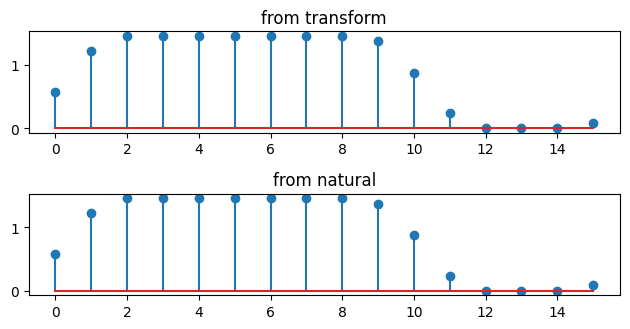

In [31]:
# plt.subplot(3,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(3,1,2), plt.stem(tf.squeeze(y).numpy()), plt.title('from transform')
plt.subplot(3,1,3), plt.stem(tf.squeeze(y1n).numpy()), plt.title('from natural')
plt.tight_layout()

In [32]:
tf.reduce_sum(tf.square(tf.squeeze(yhat))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y1n))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y))).numpy()


(np.float32(19.241398), np.float32(19.241405), np.float32(19.241402))

In [ ]:
break

2 BUILD
---

        use the layer's filter for checking equivalent output in natural domain



In [8]:
# x = [0,0,0,0,1,1,1,1]
wave = 'haar'
# wave = 'db2'
wave = 'db3'

## filter init
# h = tf.constant([1,2,3,5], dtype=tf.float32)
h = tf.squeeze(lay.h1.numpy())
# h = tf.constant([1,2,3,4], dtype=tf.float32)
# h = tf.constant([1,1,1,1], dtype=tf.float32)
# h = tf.constant([1,1], dtype=tf.float32)

# h = tf.constant([1.,5.], dtype=tf.float32)
# h = tf.constant([1,0,0,0], dtype=tf.float32)
## Matching filter size with input size with zero padding
x.shape, h.shape

(TensorShape([16]), TensorShape([4]))

        prepare hshifted (extra work)

In [9]:
L = h.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
        ]
h_padded = tf.pad(h, paddings, mode='CONSTANT', constant_values=0)
h_padded.shape


## Creating x[n-k] for all n
N = Npoint
n = tf.range(N)
row_indices = tf.math.mod(n[:, tf.newaxis]-n, N)
print(row_indices)
hshifted = tf.gather(h_padded, row_indices, axis=0)
print(x.shape, h_padded.shape, hshifted.shape), 
x, h_padded, hshifted

tf.Tensor(
[[ 0 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1]
 [ 1  0 15 14 13 12 11 10  9  8  7  6  5  4  3  2]
 [ 2  1  0 15 14 13 12 11 10  9  8  7  6  5  4  3]
 [ 3  2  1  0 15 14 13 12 11 10  9  8  7  6  5  4]
 [ 4  3  2  1  0 15 14 13 12 11 10  9  8  7  6  5]
 [ 5  4  3  2  1  0 15 14 13 12 11 10  9  8  7  6]
 [ 6  5  4  3  2  1  0 15 14 13 12 11 10  9  8  7]
 [ 7  6  5  4  3  2  1  0 15 14 13 12 11 10  9  8]
 [ 8  7  6  5  4  3  2  1  0 15 14 13 12 11 10  9]
 [ 9  8  7  6  5  4  3  2  1  0 15 14 13 12 11 10]
 [10  9  8  7  6  5  4  3  2  1  0 15 14 13 12 11]
 [11 10  9  8  7  6  5  4  3  2  1  0 15 14 13 12]
 [12 11 10  9  8  7  6  5  4  3  2  1  0 15 14 13]
 [13 12 11 10  9  8  7  6  5  4  3  2  1  0 15 14]
 [14 13 12 11 10  9  8  7  6  5  4  3  2  1  0 15]
 [15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]], shape=(16, 16), dtype=int32)
(16,) (16,) (16, 16)


(<tf.Tensor: shape=(16,), dtype=float32, numpy=
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       dtype=float32)>,
 <tf.Tensor: shape=(16,), dtype=float32, numpy=
 array([0.08515173, 0.4900027 , 0.6425366 , 0.2331385 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ], dtype=float32)>,
 <tf.Tensor: shape=(16, 16), dtype=float32, numpy=
 array([[0.08515173, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.2331385 , 0.6425366 ,
         0.4900027 ],
        [0.4900027 , 0.08515173, 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.2331385 ,
         0.6425366 ],
        [0.6425366 , 0.4900027 , 0.08515173, 0.        ,

In [10]:
hshifted[1,:] * x

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([0.4900027 , 0.08515173, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.6425366 ], dtype=float32)>

In [11]:
# tf.reverse(tf.reverse(tf.math.mod(n[:, tf.newaxis] - n, N), axis=[0]), axis=[-1])

        True value

In [12]:
res = []
for r in range(x.shape[0]):
    res.append(tf.reduce_sum(x * hshifted[r,:]))
y1n = tf.stack(res,axis=-1)
y1n
## OK

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([0.5751544 , 1.217691  , 1.4508295 , 1.4508295 , 1.4508295 ,
       1.4508295 , 1.4508295 , 1.4508295 , 1.4508295 , 1.3656778 ,
       0.8756751 , 0.2331385 , 0.        , 0.        , 0.        ,
       0.08515173], dtype=float32)>

In [13]:
DWT1D(wave, clean=False)(tf.expand_dims(tf.expand_dims(y1n, axis=0), axis=-1))

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[-1.7743610e-02],
        [ 9.5953718e-02],
        [ 1.5723537e+00],
        [ 2.0517828e+00],
        [ 2.0487833e+00],
        [ 2.0695264e+00],
        [ 1.9558291e+00],
        [ 4.8242834e-01],
        [ 1.9837938e-02],
        [ 5.7648461e-02],
        [-5.0766379e-02],
        [ 8.9406967e-08],
        [ 2.8327525e-02],
        [-1.9837886e-02],
        [-5.7648331e-02],
        [ 2.2438966e-02]]], dtype=float32)>

---

In [14]:
h.numpy(), hshifted.numpy(), hshifted[0,:].numpy(), hshifted[1,:].numpy(), x.numpy(), tf.reduce_sum(hshifted[1,:]*x).numpy() 
## OK  ## n-axis --->n

(array([0.08515173, 0.4900027 , 0.6425366 , 0.2331385 ], dtype=float32),
 array([[0.08515173, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.2331385 , 0.6425366 ,
         0.4900027 ],
        [0.4900027 , 0.08515173, 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.2331385 ,
         0.6425366 ],
        [0.6425366 , 0.4900027 , 0.08515173, 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.2331385 ],
        [0.2331385 , 0.6425366 , 0.4900027 , 0.08515173, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        ],
        [0.

In [15]:
# hshifted = tf.reverse(hshifted, axis=[1,0])
# hshifted

In [16]:
tf.expand_dims(hshifted[0:1,:], axis=-1)

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[0.08515173],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.2331385 ],
        [0.6425366 ],
        [0.4900027 ]]], dtype=float32)>

In [17]:
_ = tf.expand_dims(hshifted, axis=-1)
hinit = DWT1D(wave, clean=False)(_)
# del _
print(tf.squeeze(hinit)) # l-axis below --->l  and n-axis ^

# OK
_ = _[1:2,...]
print(tf.squeeze(_).numpy())
tf.squeeze(DWT1D(wave, clean=False)(_)).numpy() # 

tf.Tensor(
[[ 0.41017434  0.64829135  0.02832747  0.          0.          0.
   0.00821261 -0.06911444 -0.22346286  0.05300422  0.00299958  0.
   0.          0.         -0.07755831  0.24823269]
 [-0.01840124  0.8098604   0.23171768  0.          0.          0.
   0.          0.00271453  0.04008717 -0.04220338  0.02453645  0.
   0.          0.          0.         -0.02563552]
 [-0.06911443  0.41017437  0.64829135  0.02832747  0.          0.
   0.          0.00821261  0.24823268 -0.22346286  0.05300422  0.00299958
   0.          0.          0.         -0.07755831]
 [ 0.00271453 -0.01840124  0.8098604   0.23171768  0.          0.
   0.          0.         -0.02563552  0.04008716 -0.04220337  0.02453645
   0.          0.          0.          0.        ]
 [ 0.00821261 -0.06911444  0.41017437  0.64829135  0.02832747  0.
   0.          0.         -0.07755831  0.24823269 -0.22346288  0.05300422
   0.00299958  0.          0.          0.        ]
 [ 0.          0.00271453 -0.01840124  0.8098604  

array([-0.01840124,  0.8098604 ,  0.23171768,  0.        ,  0.        ,
        0.        ,  0.        ,  0.00271453,  0.04008716, -0.04220338,
        0.02453645,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.02563551], dtype=float32)

In [18]:
hinitT = tf.transpose(hinit, perm=[1,0,2])
print(hinit.shape, '\n', tf.squeeze(hinitT).numpy()) # n-axis below --->n  and ^l

(16, 16, 1) 
 [[ 0.41017434 -0.01840124 -0.06911443  0.00271453  0.00821261  0.
   0.          0.          0.          0.          0.          0.
   0.02832747  0.23171768  0.64829135  0.8098604 ]
 [ 0.64829135  0.8098604   0.41017437 -0.01840124 -0.06911444  0.00271453
   0.00821261  0.          0.          0.          0.          0.
   0.          0.          0.02832747  0.23171768]
 [ 0.02832747  0.23171768  0.64829135  0.8098604   0.41017437 -0.01840124
  -0.06911444  0.00271453  0.00821261  0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.02832747  0.23171768  0.64829135  0.8098604
   0.41017437 -0.01840124 -0.06911444  0.00271453  0.00821261  0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.02832747  0.23171768
   0.64829135  0.8098604   0.41017437 -0.01840124 -0.06911444  0.00271453
   0.00821261  0.          0.          0.        ]
 [ 0.          0.          0.   

In [19]:
H = DWT1D(wave, clean=False)(hinitT)

print(tf.squeeze(hinitT).numpy(), '\n\n', tf.squeeze(H).numpy())

##OK
print('\n\n',tf.squeeze(hinitT[0:1,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[0:1,...])).numpy())
print('\n',tf.squeeze(hinitT[1:2,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[1:2,...])).numpy())
## v-axis below --->v and ^l

[[ 0.41017434 -0.01840124 -0.06911443  0.00271453  0.00821261  0.
   0.          0.          0.          0.          0.          0.
   0.02832747  0.23171768  0.64829135  0.8098604 ]
 [ 0.64829135  0.8098604   0.41017437 -0.01840124 -0.06911444  0.00271453
   0.00821261  0.          0.          0.          0.          0.
   0.          0.          0.02832747  0.23171768]
 [ 0.02832747  0.23171768  0.64829135  0.8098604   0.41017437 -0.01840124
  -0.06911444  0.00271453  0.00821261  0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.02832747  0.23171768  0.64829135  0.8098604
   0.41017437 -0.01840124 -0.06911444  0.00271453  0.00821261  0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.02832747  0.23171768
   0.64829135  0.8098604   0.41017437 -0.01840124 -0.06911444  0.00271453
   0.00821261  0.          0.          0.        ]
 [ 0.          0.          0.          0.     

In [20]:
HT = tf.transpose(H, perm=[1,0,2])
print(HT.shape, '\n', tf.squeeze(HT).numpy())   ## l-axis below --->l and ^v
# HT=H

(16, 16, 1) 
 [[ 3.49495232e-01 -4.51197326e-02  5.74221928e-03  0.00000000e+00
   2.73209182e-03 -1.70252118e-02  8.87527540e-02  1.06625199e+00
   7.13745654e-02 -7.94866867e-03  6.08040311e-04  0.00000000e+00
  -2.58013643e-02  2.62273010e-02  8.22508559e-02 -1.46710724e-01]
 [ 1.06625211e+00  3.49495232e-01 -4.51197289e-02  5.74221928e-03
   0.00000000e+00  2.73209182e-03 -1.70252118e-02  8.87527615e-02
  -1.46710709e-01  7.13745654e-02 -7.94866867e-03  6.08040311e-04
   0.00000000e+00 -2.58013643e-02  2.62273028e-02  8.22508559e-02]
 [ 8.87527466e-02  1.06625211e+00  3.49495232e-01 -4.51197289e-02
   5.74221928e-03  0.00000000e+00  2.73209182e-03 -1.70252118e-02
   8.22508708e-02 -1.46710709e-01  7.13745654e-02 -7.94866867e-03
   6.08040311e-04  0.00000000e+00 -2.58013643e-02  2.62273010e-02]
 [-1.70252100e-02  8.87527540e-02  1.06625211e+00  3.49495232e-01
  -4.51197289e-02  5.74221928e-03  0.00000000e+00  2.73209182e-03
   2.62273010e-02  8.22508633e-02 -1.46710709e-01  7.137456

        H[v,l] 

In [21]:
_ = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
print('x:= ', _.shape, _[0,:,0].numpy())
α = DWT1D(wave, clean=False)(_)

# α = IDWT1D(wave)(_)
# α = IDWT1D(wave)(α)

print('α:= ', α.shape, tf.squeeze(α).numpy())

x:=  (1, 16, 1) [1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1.]
α:=  (1, 16, 1) [-1.8522599e-01  1.0815430e+00  1.4142135e+00  1.4142135e+00
  1.3789872e+00  1.5994395e+00  3.3267054e-01  3.5226293e-02
  1.4343470e-02 -3.5226271e-02  2.9802322e-08  2.9802322e-08
  3.3267057e-01 -1.4343448e-02  3.5226293e-02 -3.3267054e-01]


In [22]:
HT[0,:,0].numpy().shape, α[0,:,0].numpy().shape
# (HT[0,:,0] * α[0,:,0])

((16,), (16,))

In [23]:
print('\n', HT[0,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[0,:,0] * α[0,:,0]).numpy())
print('\n', HT[1,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[1,:,0] * α[0,:,0]).numpy())
# print('\n', HT[2,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[2,:,0] * α[0,:,0]).numpy())
# print('\n', HT[3,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[3,:,0] * α[0,:,0]).numpy())
# 5.5 * 5.656854, 2.4999998*16.970562


 [ 3.4949523e-01 -4.5119733e-02  5.7422193e-03  0.0000000e+00
  2.7320918e-03 -1.7025212e-02  8.8752754e-02  1.0662520e+00
  7.1374565e-02 -7.9486687e-03  6.0804031e-04  0.0000000e+00
 -2.5801364e-02  2.6227301e-02  8.2250856e-02 -1.4671072e-01] 
 [-1.8522599e-01  1.0815430e+00  1.4142135e+00  1.4142135e+00
  1.3789872e+00  1.5994395e+00  3.3267054e-01  3.5226293e-02
  1.4343470e-02 -3.5226271e-02  2.9802322e-08  2.9802322e-08
  3.3267057e-01 -1.4343448e-02  3.5226293e-02 -3.3267054e-01] 
 [-6.4735599e-02 -4.8798930e-02  8.1207240e-03  0.0000000e+00
  3.7675197e-03 -2.7230795e-02  2.9525427e-02  3.7560105e-02
  1.0237590e-03  2.8000196e-04  1.8121013e-11  0.0000000e+00
 -8.5833548e-03 -3.7618991e-04  2.8973927e-03  4.8806336e-02]

 [ 1.0662521e+00  3.4949523e-01 -4.5119729e-02  5.7422193e-03
  0.0000000e+00  2.7320918e-03 -1.7025212e-02  8.8752761e-02
 -1.4671071e-01  7.1374565e-02 -7.9486687e-03  6.0804031e-04
  0.0000000e+00 -2.5801364e-02  2.6227303e-02  8.2250856e-02] 
 [-1.852259

In [24]:
α[0,:,0]  * HT[0,:,0]

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-6.4735599e-02, -4.8798930e-02,  8.1207240e-03,  0.0000000e+00,
        3.7675197e-03, -2.7230795e-02,  2.9525427e-02,  3.7560105e-02,
        1.0237590e-03,  2.8000196e-04,  1.8121013e-11,  0.0000000e+00,
       -8.5833548e-03, -3.7618991e-04,  2.8973927e-03,  4.8806336e-02],
      dtype=float32)>

        look

In [25]:
HTα = HT * α
print(HTα.shape, '\n', tf.squeeze(HTα).numpy())

(16, 16, 1) 
 [[-6.47355989e-02 -4.87989299e-02  8.12072400e-03  0.00000000e+00
   3.76751972e-03 -2.72307955e-02  2.95254271e-02  3.75601053e-02
   1.02375902e-03  2.80001957e-04  1.81210134e-11  0.00000000e+00
  -8.58335476e-03 -3.76189913e-04  2.89739273e-03  4.88063358e-02]
 [-1.97497606e-01  3.77994120e-01 -6.38089329e-02  8.12072400e-03
   0.00000000e+00  4.36981535e-03 -5.66378655e-03  3.12643079e-03
  -2.10434059e-03 -2.51425966e-03 -2.36888786e-10  1.81210134e-11
   0.00000000e+00  3.70080525e-04  9.23890679e-04 -2.73624361e-02]
 [-1.64393149e-02  1.15319753e+00  4.94260877e-01 -6.38089329e-02
   7.91844726e-03  0.00000000e+00  9.08886432e-04 -5.99735125e-04
   1.17976288e-03  5.16807102e-03  2.12712781e-09 -2.36888786e-10
   2.02277122e-04 -0.00000000e+00 -9.08886432e-04 -8.72505084e-03]
 [ 3.15351132e-03  9.59899202e-02  1.50790823e+00  4.94260877e-01
  -6.22195266e-02  9.18433256e-03  0.00000000e+00  9.62414633e-05
   3.76190525e-04 -2.89739110e-03 -4.37231984e-09  2.127127

In [26]:
93.33809   -15.909902  + 70.00357    -0.3535534
# 93.33809-42.4264+93.33809+8.485281
# 93.33809+35.001785-42.4264+15.909902

147.0782046

In [27]:
beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
# beta = tf.expand_dims(tf.einsum('ijk->jk',HTα), axis=-1)
βT = tf.transpose(beta, perm=[1,0,2])
print(beta.shape, βT.shape, '\n', tf.squeeze(βT))

(16, 1, 1) (1, 16, 1) 
 tf.Tensor(
[-1.7743599e-02  9.5953703e-02  1.5723541e+00  2.0517824e+00
  2.0487831e+00  2.0695260e+00  1.9558288e+00  4.8242831e-01
  1.9837923e-02  5.7648331e-02 -5.0766438e-02 -1.8451829e-08
  2.8327467e-02 -1.9837910e-02 -5.7648342e-02  2.2438977e-02], shape=(16,), dtype=float32)


In [28]:
yhat = IDWT1D(wave, clean=False)(βT)#
yhat

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[ 5.7515442e-01],
        [ 1.2176911e+00],
        [ 1.4508294e+00],
        [ 1.4508291e+00],
        [ 1.4508293e+00],
        [ 1.4508295e+00],
        [ 1.4508293e+00],
        [ 1.4508291e+00],
        [ 1.4508291e+00],
        [ 1.3656775e+00],
        [ 8.7567490e-01],
        [ 2.3313846e-01],
        [-2.5611371e-09],
        [ 1.8626451e-09],
        [ 1.6763806e-08],
        [ 8.5151717e-02]]], dtype=float32)>

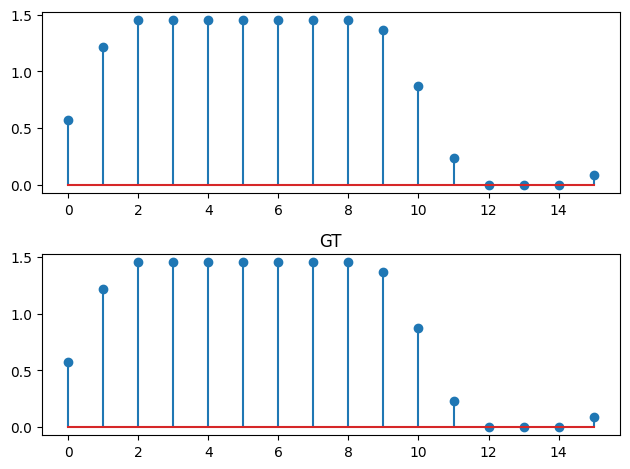

In [29]:
plt.subplot(2,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(2,1,2), plt.stem(tf.squeeze(y1n).numpy()), plt.title('GT')
plt.tight_layout()


In [30]:
tf.reduce_sum(tf.square(yhat)), tf.reduce_sum(tf.square(y1n)), 

(<tf.Tensor: shape=(), dtype=float32, numpy=19.241397857666016>,
 <tf.Tensor: shape=(), dtype=float32, numpy=19.241405487060547>)